In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [4]:
# Import the cifar10 dataset
from keras.datasets import cifar10

# Set the training and test images + labels
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [5]:
import keras
from keras import layers

# Create a stack of layers
model = keras.Sequential(
    [
        # Create a tensor in the shape of a 32x32 grid with three color channels for RGB
        keras.Input(shape=(32, 32, 3)),

        # A conv2D layer -- 32 kernels which scan the image in 3x3 grids to detect patterns
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        # Takes the max value over an input to downsample it for performance
        layers.MaxPooling2D(pool_size=(2, 2)),

        # A conv2D layer -- Uses 64 kernels to detect complex shapes from the simplified maps
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        # Shrinks the spatial dimensions even further
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Flattens the input
        layers.Flatten(),
        # Densely-connected -- outputs input if positive, else returns zero
        layers.Dense(64, activation="relu"),
        # Transforms output to a probability distribution
        layers.Dense(10, activation="softmax")
    ]
)

In [6]:
model.compile(
    # Uses the "adam" optimizer to update itself
    optimizer="adam",
    # Measures the performance of the training data
    loss="sparse_categorical_crossentropy",
    # Used to monitor performance
    metrics=["accuracy"]
)

In [7]:
# Train model and save the history
history = model.fit(
    train_images,
    train_labels,
    batch_size=64,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3865 - loss: 2.0368 - val_accuracy: 0.4798 - val_loss: 1.4594
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5305 - loss: 1.3328 - val_accuracy: 0.5616 - val_loss: 1.2545
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.5867 - loss: 1.1801 - val_accuracy: 0.5944 - val_loss: 1.1687
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6268 - loss: 1.0640 - val_accuracy: 0.5976 - val_loss: 1.1724
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6635 - loss: 0.9673 - val_accuracy: 0.6102 - val_loss: 1.1539
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6864 - loss: 0.9008 - val_accuracy: 0.6419 - val_loss: 1.0634
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7119 - loss: 0.8245 - val_accuracy: 0.6183 - val_loss: 1.2025
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7301 - loss: 0.7750 - 

In [8]:
# Evaluate how accurate the model is
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Final Test Accuracy: {test_acc}")

313/313 - 1s - 3ms/step - accuracy: 0.6427 - loss: 1.1748
Final Test Accuracy: 0.6427000164985657


In [9]:
# Making a Prediction
import numpy as np

# Order of the 10 classes in the dataset
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Retrieves the first test image
image_to_predict = test_images[0]

# Reshape the test image
image_batch = np.expand_dims(image_to_predict, axis=0)

# Have model predict what the test image is
raw_predictions = model.predict(image_batch)

# Find the class with the highest probability (what the model thinks the image is)
predicted_class = np.argmax(raw_predictions[0])

print(f"Raw Output Probabilities: {raw_predictions[0]}")
print(f"The model confidently predicts this is a: {cifar10_classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Raw Output Probabilities: [1.5640608e-04 2.1119865e-04 3.0328093e-02 4.7247961e-01 2.7721883e-03
 4.3720552e-01 4.8350543e-02 2.6186620e-04 8.2114004e-03 2.3113851e-05]
The model confidently predicts this is a: cat


In [10]:
import numpy as np
from keras.preprocessing import image

# Order of the 10 classes in the dataset
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Upload image
img = image.load_img("../data/airplane.jpg", target_size=(32, 32))

# Test image
image_to_predict = image.img_to_array(img)

# Reshape image
image_batch = np.expand_dims(image_to_predict, axis=0)

# Run model on test image
raw_predictions = model.predict(image_batch)

# Find class with highest probability
predicted_class = np.argmax(raw_predictions[0])

print(f"Raw Output Probabilities: {raw_predictions[0]}")
print(f"The model confidently predicts this is a: {cifar10_classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Raw Output Probabilities: [8.7669641e-01 4.1131885e-03 1.9804534e-02 7.4644446e-02 6.8670948e-04
 2.0316758e-03 3.7584838e-04 6.3533324e-04 2.0906501e-02 1.0529018e-04]
The model confidently predicts this is a: airplane


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


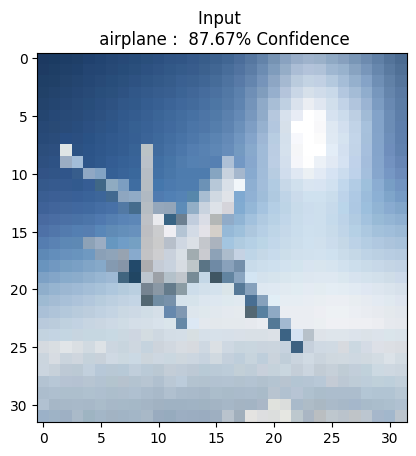

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


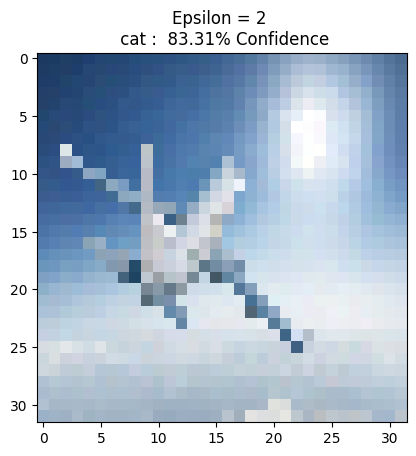

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


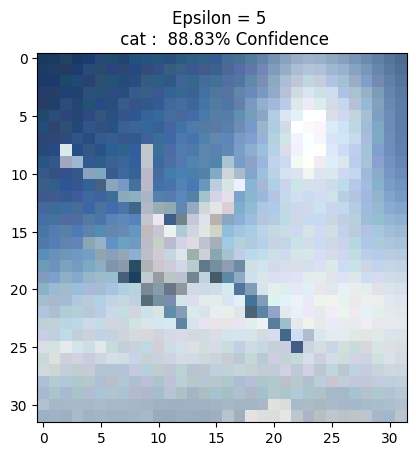

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


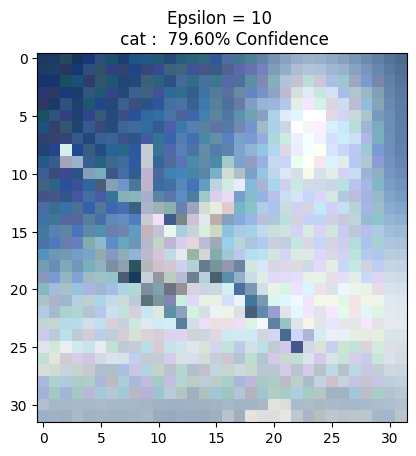

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


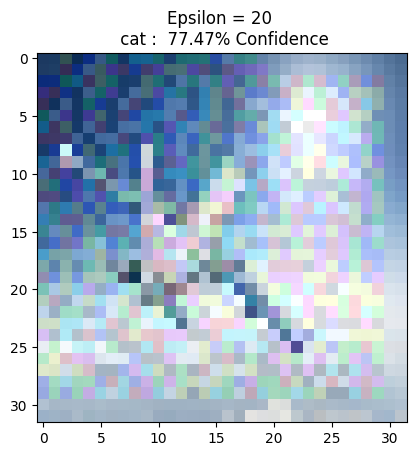

In [11]:
## Phase 2 - Fast Gradient Signed Method Attack
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Update loss for CIFAR-10 integers
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def create_adversarial_pattern(input_image, input_label):
  with tf.GradientTape() as tape:
    # Tape watches the image's pixels
    tape.watch(input_image)
    prediction = model(input_image)
    loss = loss_object(input_label, prediction)

  # Get gradient of loss w.r.t the input image
  gradient = tape.gradient(loss, input_image)

  # Get the sign of the gradients to create the pertubation
  signed_grad = tf.sign(gradient)
  return signed_grad

def display_images(image, description):

  # Get prediction using model
  raw_predictions = model.predict(image)

  # Find index and confidence of the highest guess
  predicted_index = np.argmax(raw_predictions[0])
  confidence = raw_predictions[0][predicted_index]

  # Class with highest probability
  label = cifar10_classes[predicted_index]

  # Display as 2d image
  plt.figure()
  # Divide by 255 because Matplotlib prefers floats btw 0-1
  plt.imshow(image[0] / 255.0)
  plt.title('{} \n {} :  {:.2f}% Confidence'.format(description,
                                                    label, confidence * 100))
  plt.show()

# Convert image to tensor
image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

# Create the pertubation (input is the image tensor and its true label)
perturbations = create_adversarial_pattern(image_tensor, tf.constant([0]))

epsilons = [0, 2, 5, 10, 20]
descriptions = [('Epsilon = {}'.format(eps) if eps else 'Input')
                for eps in epsilons]

# Breaking point @ epsilon 5
for i, eps in enumerate(epsilons):
  # Add noise to image
  adv_x = image_tensor + (eps * perturbations)

  # Clip pixels so they stay valid colors
  adv_x = tf.clip_by_value(adv_x, 0, 255)

  display_images(adv_x, descriptions[i])

In [12]:
# Generate the defense dataset
import tensorflow as tf
import numpy as np

eps = 5
adv_imgs = []
adv_labels = []
for i  in range(1000):
  img = train_images[i]
  label = train_labels[i]

  # Reshape image
  image_batch = np.expand_dims(img, axis=0)

  # Convert image to tensor
  image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

  # Create perturbation
  perturbation = create_adversarial_pattern(image_tensor, tf.constant([label]))

  # Add the noise to image
  adv_x = image_tensor + (eps * perturbation)

  # Clip pixels
  adv_x = tf.clip_by_value(adv_x, 0, 255)

  # Add images and label to defense dataset
  # Strip the batch dimension by taking index 0
  adv_imgs.append(adv_x[0])
  adv_labels.append(label)

# Convert lists into numpy arrays
adv_imgs = np.array(adv_imgs)
adv_labels = np.array(adv_labels)

print(f"Successfully generated {len(adv_imgs)} adversarial images!")

Successfully generated 1000 adversarial images!


In [13]:
## Phase 3 - Vaccine
import numpy as np

clean_imgs = train_images[1000:2000]
clean_labels = train_labels[1000:2000]

# Combine the clean images with the adversarial images
combined_imgs = np.concatenate((adv_imgs, clean_imgs))
combined_labels = np.concatenate((adv_labels, clean_labels))

# Shuffle clean + adversarial images
indices = np.arange(len(combined_imgs))
np.random.shuffle(indices)

shuffled_imgs = combined_imgs[indices]
shuffled_labels = combined_labels[indices]

print(f"Vaccine mix ready! Total images: {len(shuffled_imgs)}")

Vaccine mix ready! Total images: 2000


In [14]:
model.fit(shuffled_imgs, shuffled_labels, batch_size=64, epochs=4, validation_data=(test_images, test_labels))

Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3785 - loss: 2.1433 - val_accuracy: 0.4533 - val_loss: 1.6246
Epoch 2/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.4435 - loss: 1.5323 - val_accuracy: 0.5011 - val_loss: 1.3986
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5290 - loss: 1.3205 - val_accuracy: 0.5334 - val_loss: 1.3725
Epoch 4/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5850 - loss: 1.1520 - val_accuracy: 0.5306 - val_loss: 1.3911


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


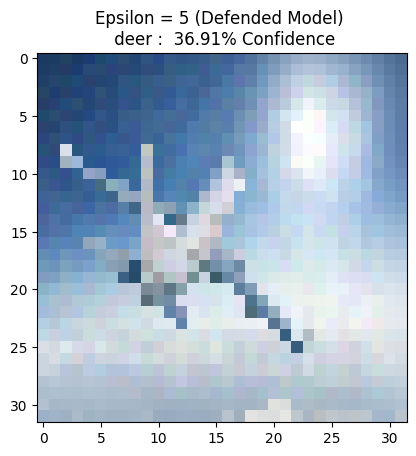

In [15]:
img = image.load_img("../data/airplane.jpg", target_size=(32, 32))

image_to_predict = image.img_to_array(img)

image_batch = np.expand_dims(image_to_predict, axis=0)

# Convert image to a tensor
image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

# Generate an adversarial pattern based on new model's gradients
perturbations = create_adversarial_pattern(image_tensor, tf.constant([0]))

# Apply the exact same Epsilon = 5 noise that broke the model
eps = 5
adv_x = image_tensor + (eps * perturbations)
adv_x = tf.clip_by_value(adv_x, 0, 255)

# Display the image and the new model's prediction!
display_images(adv_x, 'Epsilon = 5 (Defended Model)')

In [16]:
model.save('defended_model.keras')

Loading baseline model...
Generating attacks...


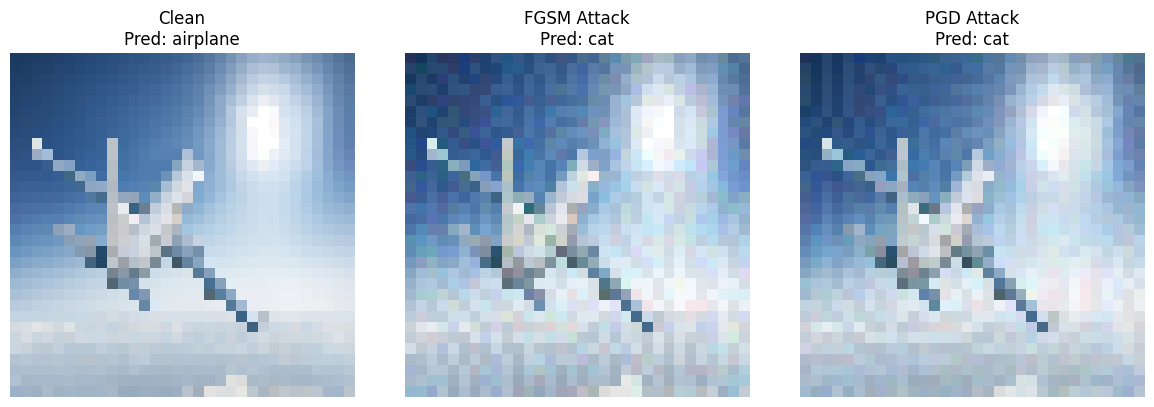

In [17]:
import sys
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image

# Step 1: Tell the notebook where the src/ directory is
sys.path.append(os.path.abspath(".."))
from src.attacks import fast_gradient_sign_method, projected_gradient_descent

# Step 2: Load your trained baseline model 
# (Keras automatically restores architecture + weights)
print("Loading baseline model...")
model = tf.keras.models.load_model("../models/baseline_vgg.keras")

# Step 3: Load and preprocess the airplane image
img = image.load_img("../data/airplane.jpg", target_size=(32, 32))
img_array = image.img_to_array(img).astype("float32") / 255.0
img_batch = np.expand_dims(img_array, axis=0)
img_tensor = tf.convert_to_tensor(img_batch)

# CIFAR-10 class labels for mapping predictions
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
true_label = tf.constant([0]) # 0 is the index for 'airplane'

# Step 4: Generate Adversarial Images
print("Generating attacks...")
epsilon = 8/255  # Total allowed perturbation budget

# Run your custom FGSM and PGD functions
img_fgsm = fast_gradient_sign_method(model, img_tensor, true_label, epsilon)
img_pgd = projected_gradient_descent(model, img_tensor, true_label, epsilon, alpha=2/255, num_iter=10)

# Step 5: Run Predictions
pred_clean = classes[np.argmax(model.predict(img_tensor, verbose=0))]
pred_fgsm = classes[np.argmax(model.predict(img_fgsm, verbose=0))]
pred_pgd = classes[np.argmax(model.predict(img_pgd, verbose=0))]

# Step 6: Plot the Results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_tensor[0])
axes[0].set_title(f"Clean\nPred: {pred_clean}")
axes[0].axis('off')

axes[1].imshow(img_fgsm[0])
axes[1].set_title(f"FGSM Attack\nPred: {pred_fgsm}")
axes[1].axis('off')

axes[2].imshow(img_pgd[0])
axes[2].set_title(f"PGD Attack\nPred: {pred_pgd}")
axes[2].axis('off')

plt.tight_layout()
plt.show()